### Analisis pelicula radiocromica diario de braquiterapia

Este analisis debe verificar la coincidencia entre los puntos donde para la fuente frente a las lineas que dibuja correspondientes a la posicion de referencia de cada parada, es decir, debe coincidir el centro del perfil de radiacion con la linea indicadora del perfil de cada parada.

Como siempre, si vamos a hacer cortes a lo largo de los ejes es importantisimo garantizar la alineacion.

### Librerias

In [59]:
import numpy as np
import scipy as sp
from scipy.fft import fft2
from scipy.fft import ifft2
from scipy.fft import fftfreq
from scipy.fft import fftshift, ifftshift
from scipy.signal import convolve2d

import imageio

import os
import cv2
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import animation
from matplotlib.animation import PillowWriter
from matplotlib import colormaps
import pint
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider, IntSlider, Layout, HBox, VBox

from PIL import Image

u = pint.UnitRegistry()



### Funciones auxiliares

In [60]:
def normalize_image(image):
    normalized_image = (image - np.min(image)) / (np.max(image) - np.min(image))
    return normalized_image

def intensidad_del_campo(campo):
    intensidad_espectro_imagen = np.abs(campo)**2
    return intensidad_espectro_imagen

## Placa a analizar

Hay que recordar no poner las mismas claves a todas las funciones de estos analisis una vez se implementen en la aplicacion, puede generar errores, importante tenerlo en cuenta.

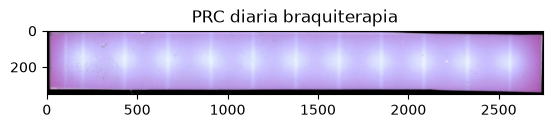

In [61]:
ruta_imagen = '/home/felipepp/Documents/CodigosPython/ImagenesDeReferencia/PlacasHistoricas/EPSON004.JPG'

placa_analizada = cv2.bitwise_not(cv2.imread(ruta_imagen, 1))
placa_analizada_gray = cv2.bitwise_not(cv2.imread(ruta_imagen, 0))

plt.imshow(placa_analizada)
plt.title('PRC diaria braquiterapia')
plt.show()

In [62]:
tamano_pixel = 25.4/600 # Tamano del pixel a 600 dpi

Aqui es muy importante decidir si se va a ubicar algun punto de referencia de forma manual, lo dudo mucho, poner un punto por cada linea requeriria sacar una linea de tendencia a las posiciones de todos esos valores y luego a partir de esa linea analizarlo, que en primer lugar no es confiable.

Y menos necesario debido a que si tenemos ya las lineas de referencia, ahora hay que pensar cual es la mejor forma de garantizar alineacion.

Marcar puntos sobre todas las lineas puede ser excesivo, innecesario y hacernos incurrir mas rapidamente en errores, por lo cual podemos simplemente usar la primer linea, y hacer el mismo analisis que para posicion inicial de braquiterapia.

Puntos guardados (coordenadas [x, y]): [(109, 21), (107, 311)]


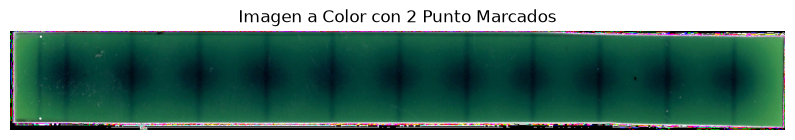

In [63]:
# --- 1. Aplicar mapa de color a la imagen base ---
# Convertimos el float32 [0.0, 1.0] a uint8 [0, 255] para aplicar el mapa de color de OpenCV
img_uint8 = (placa_analizada* 255).clip(0, 255).astype(np.uint8)

# Aplicar mapa de color (Puedes cambiar cv2.COLORMAP_JET por:
# COLORMAP_VIRIDIS, COLORMAP_HOT, COLORMAP_TURBO, COLORMAP_PLASMA, COLORMAP_BONE)
# placa_color_bgr = cv2.applyColorMap(img_uint8, cv2.COLORMAP_JET)

# Convertir de vuelta a float32 [0.0, 1.0] para trabajar uniformemente
placa_color = img_uint8.astype(np.float32) / 255.0

puntos = []


def seleccionar_puntos(event, x, y, flags, param):
    global puntos, placa_color

    if event == cv2.EVENT_LBUTTONDOWN and len(puntos) < 2:
        puntos.append((x, y))

        # Dibujar punto con intensidad de contraste sobre el mapa de calor
        # (1.0, 1.0, 1.0) = Blanco puro | (0.0, 0.0, 0.0) = Negro puro
        cv2.circle(placa_color, (x, y), 4, (1.0, 1.0, 1.0), -1)


# --- 2. Interfaz interactiva OpenCV ---
cv2.namedWindow("Seleccionar 2 Puntos", cv2.WINDOW_NORMAL)
cv2.setMouseCallback("Seleccionar 2 Puntos", seleccionar_puntos)
cv2.resizeWindow("Seleccionar 2 Puntos", 1280, 720)

while True:
    cv2.imshow("Seleccionar 2 Puntos", placa_color)

    key = cv2.waitKey(1) & 0xFF
    if key == 27 or len(puntos) == 2:
        if len(puntos) == 2:
            cv2.imshow("Seleccionar 2 Punto", placa_color)
            cv2.waitKey(300)
        break

cv2.destroyAllWindows()
cv2.waitKey(1)

# --- 3. Renderizado inline dentro del Notebook ---
print(f"Puntos guardados (coordenadas [x, y]): {puntos}")

# Convertir BGR a RGB para mostrar exactamente lo mismo en Matplotlib
placa_color_rgb = cv2.cvtColor(
    (placa_color * 255).astype(np.uint8), cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 6))
plt.imshow(placa_color_rgb)
plt.title("Imagen a Color con 2 Punto Marcados")
plt.axis("off")
plt.show()

Estos dos puntos van a ser nuestro indicador... Creo que puede ser de mucha utilidad recordar que hay una distancia especifica que si no estoy mal es de 10 mm entre cada linea, por lo cual debe haber una cantidad particular de pixeles al recorrer todas esas lineas y entre ellas. Solo con los dos puntos parece que no se pasa exactamente por el centro de los perfiles, sera esto culpa de la calidad de la pelicula o efecto del analisis.

### Angulo de rotacion

Igual podemos alinear de una vez la placa.

In [64]:
tetha_0 = -1 * np.degrees(np.arctan((puntos[1][0] - puntos[0][0])/(puntos[1][1] - puntos[0][1])))
print(tetha_0)

0.39513704250748827


In [65]:
centro_rotacion = ((puntos[1][0] + puntos[0][0])//2, (puntos[1][1] + puntos[0][1])//2)

print(centro_rotacion)

(108, 166)


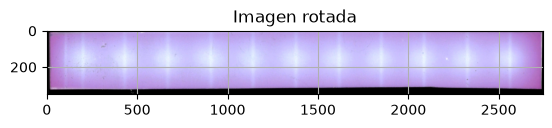

In [66]:
placa_matriz_transformacion = cv2.getRotationMatrix2D(
    centro_rotacion,
    tetha_0, 1)

placa_rotada = cv2.warpAffine(placa_analizada, 
                               placa_matriz_transformacion, 
                               (np.shape(placa_color_rgb)[1], np.shape(placa_color_rgb)[0]))

plt.imshow(placa_rotada, cmap = 'jet')
plt.title('Imagen rotada')
plt.grid()
plt.show()

### Nuevos puntos

Recordemos que debemos considerar aun conservar la posicion de los puntos marcados, pero como la rotacion se hace sobre el centro entre estos dos puntos estas posiciones no se conservan.

In [67]:
arr_puntos = np.array(puntos)

puntos_rotados_tetha = cv2.transform(
    arr_puntos.reshape(-1, 1, 2),
    placa_matriz_transformacion
)

puntos_rotados_tetha = puntos_rotados_tetha.reshape(-1, 2).tolist()

print(f"Nueva posicion puntos de referencia: {puntos_rotados_tetha}")

Nueva posicion puntos de referencia: [[108, 21], [108, 311]]


Importante recordar que pusimos estos puntos en los bordes pero estos bordes pueden no estar bien cortados, esto significa que si trazamos un corte exactamente en este punto crossplane puede que no nos encontremos con algunas de las lineas, por lo que solo debemos bajar algunos pixeles o subir para pasar por todas.

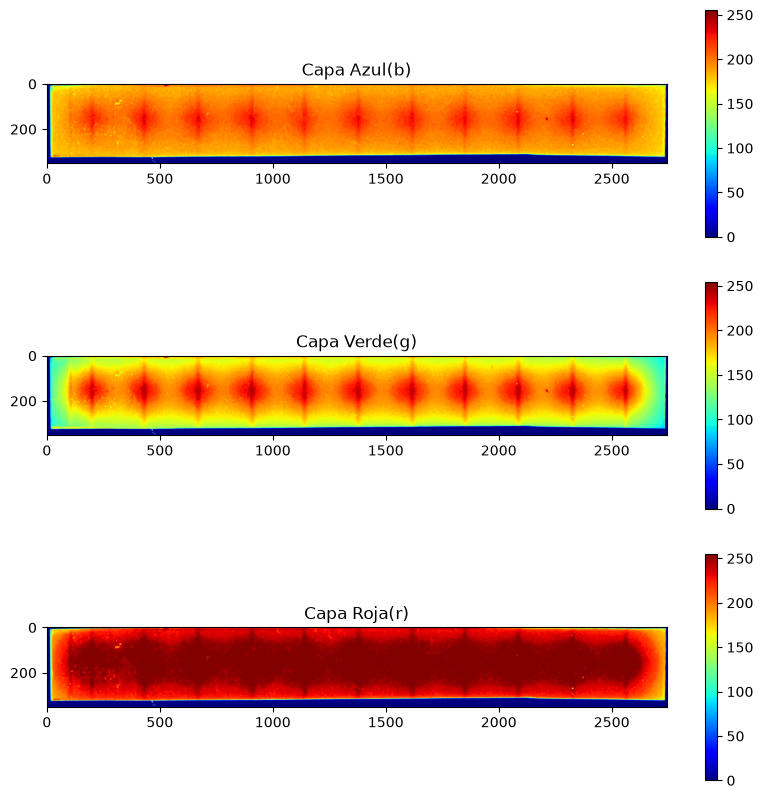

In [68]:
b, g, r = cv2.split(placa_rotada)

plt.figure(figsize = (10, 10))

plt.subplot(3, 1, 1)
plt.imshow(b, cmap = 'jet')
plt.colorbar()
plt.title('Capa Azul(b)')

plt.subplot(3, 1, 2)
plt.imshow(g, cmap = 'jet')
plt.colorbar()
plt.title('Capa Verde(g)')

plt.subplot(3, 1, 3) # Numero filas, columnas, posicion especifica.
plt.imshow(r, cmap = 'jet')
plt.colorbar()
plt.title('Capa Roja(r)')

plt.show()

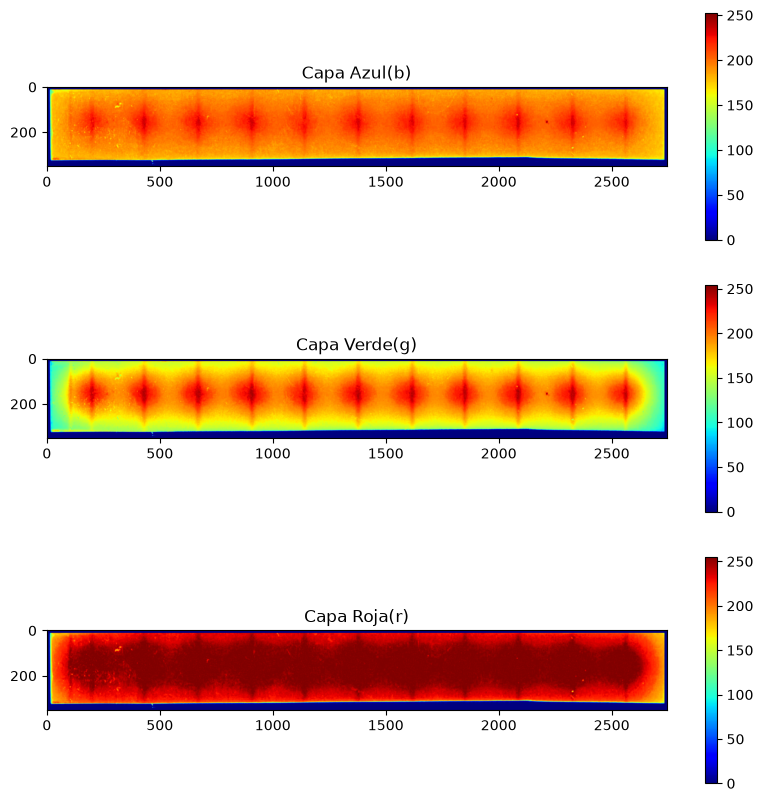

In [69]:
grosor_marco = 20

rectangulo_borde_b = cv2.rectangle(b, (0, 0), (np.shape(b)[1], np.shape(b)[0]), 0, grosor_marco)
rectangulo_borde_g = cv2.rectangle(g, (0, 0), (np.shape(g)[1], np.shape(g)[0]), 0, grosor_marco)
rectangulo_borde_r = cv2.rectangle(r, (0, 0), (np.shape(r)[1], np.shape(r)[0]), 0, grosor_marco)

plt.figure(figsize = (10, 10))

plt.subplot(3, 1, 1)
plt.imshow(rectangulo_borde_b, cmap = 'jet')
plt.colorbar()
plt.title('Capa Azul(b)')

plt.subplot(3, 1, 2)
plt.imshow(rectangulo_borde_g, cmap = 'jet')
plt.colorbar()
plt.title('Capa Verde(g)')

plt.subplot(3, 1, 3)
plt.imshow(rectangulo_borde_r, cmap = 'jet')
plt.colorbar()
plt.title('Capa Roja(r)')

plt.show()

In [70]:
zona_ignorada = int(grosor_marco * 1.25)

valor_pelicula_b = int(rectangulo_borde_b[
    zona_ignorada
][
    zona_ignorada
])
print(f"Valor de centro blue: {valor_pelicula_b}")

valor_pelicula_g = int(rectangulo_borde_g[
    zona_ignorada
][
    zona_ignorada
])
print(f"Valor de centro green: {valor_pelicula_g}")

valor_pelicula_r = int(rectangulo_borde_r[
    zona_ignorada
][
    zona_ignorada
])
print(f"Valor de centro red: {valor_pelicula_r}")

Valor de centro blue: 128
Valor de centro green: 101
Valor de centro red: 160


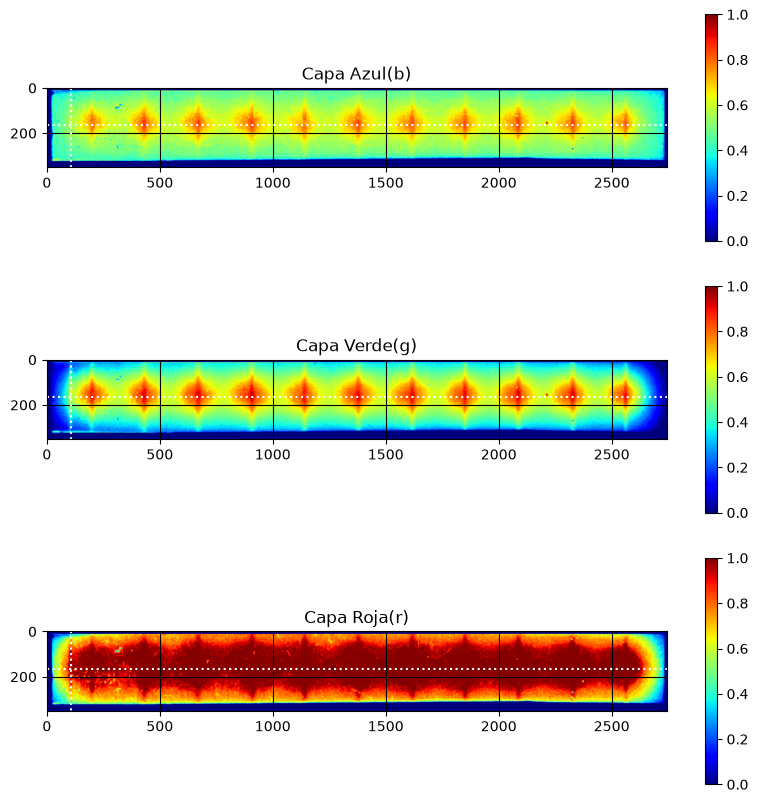

In [71]:
placa_recorte_borde_b = normalize_image(
    np.where(
        rectangulo_borde_b <= valor_pelicula_b,
        valor_pelicula_b, rectangulo_borde_b
    )
)
placa_recorte_borde_g = normalize_image(
    np.where(
        rectangulo_borde_g <= valor_pelicula_g,
        valor_pelicula_g, rectangulo_borde_g
    )
)
placa_recorte_borde_r = normalize_image(
    np.where(
        rectangulo_borde_r <= valor_pelicula_r,
        valor_pelicula_r, rectangulo_borde_r
    )
)


plt.figure(figsize = (10, 10))

plt.subplot(3, 1, 1)
plt.imshow(placa_recorte_borde_b, cmap = 'jet')
plt.vlines(centro_rotacion[0], 0,
           np.shape(placa_recorte_borde_b)[0] - 1,
           colors = 'white', linestyles = ':')
plt.hlines(centro_rotacion[1], 0,
           np.shape(placa_recorte_borde_b)[1] - 1,
           colors = 'white', linestyles = ':')
plt.colorbar()
plt.grid(True, color = 'black')
plt.title('Capa Azul(b)')

plt.subplot(3, 1, 2)
plt.imshow(placa_recorte_borde_g, cmap = 'jet')
plt.vlines(centro_rotacion[0], 0,
           np.shape(placa_recorte_borde_g)[0] - 1,
           colors = 'white', linestyles = ':')
plt.hlines(centro_rotacion[1], 0,
           np.shape(placa_recorte_borde_g)[1] - 1,
           colors = 'white', linestyles = ':')
plt.colorbar()
plt.grid(True, color = 'black')
plt.title('Capa Verde(g)')

plt.subplot(3, 1, 3)
plt.imshow(placa_recorte_borde_r, cmap = 'jet')
plt.vlines(centro_rotacion[0], 0,
           np.shape(placa_recorte_borde_r)[0] - 1,
           colors = 'white', linestyles = ':')
plt.hlines(centro_rotacion[1], 0,
           np.shape(placa_recorte_borde_r)[1] - 1,
           colors = 'white', linestyles = ':')
plt.colorbar()
plt.grid(True, color = 'black')
plt.title('Capa Roja(r)')

plt.show()

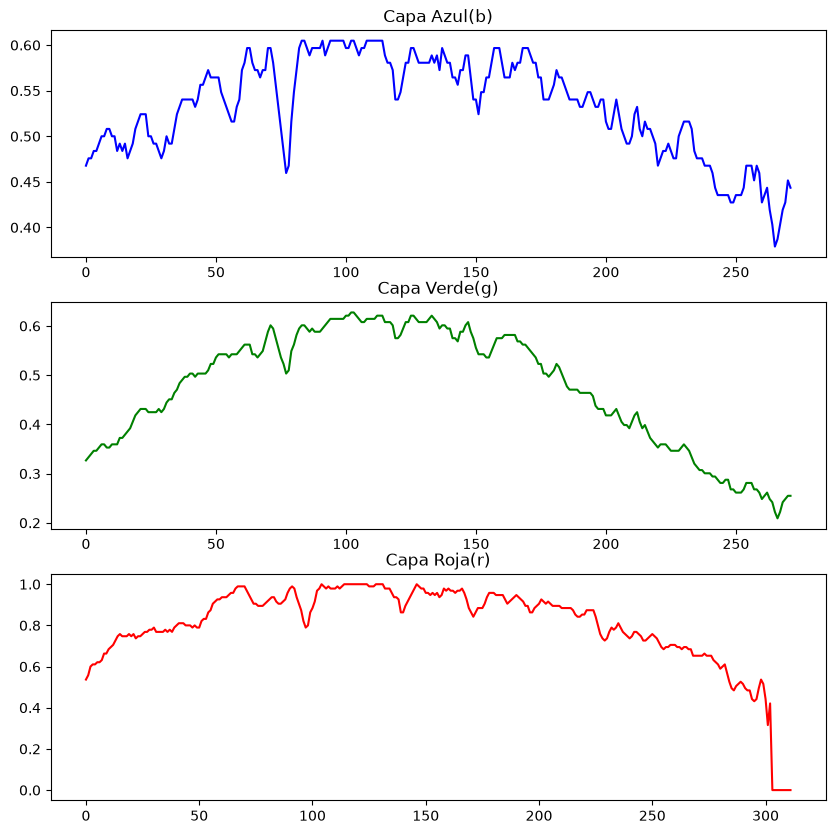

In [72]:
b_inplane = np.rot90(placa_recorte_borde_b)[
    np.shape(placa_recorte_borde_r)[1] - centro_rotacion[0]
][grosor_marco:np.shape(placa_recorte_borde_b)[0] - grosor_marco]

g_inplane = np.rot90(placa_recorte_borde_g)[
    np.shape(placa_recorte_borde_r)[1] - centro_rotacion[0]
][grosor_marco:np.shape(placa_recorte_borde_g)[0] - grosor_marco]

r_inplane = np.rot90(placa_recorte_borde_r)[
    np.shape(placa_recorte_borde_r)[1] - centro_rotacion[0]
][grosor_marco:np.shape(placa_recorte_borde_r)[0] - grosor_marco]

plt.figure(figsize = (10, 10))

plt.subplot(3, 1, 1)
plt.plot(b_inplane[grosor_marco:np.shape(b_inplane)[0] - grosor_marco], color = 'blue')
plt.title('Capa Azul(b)')

plt.subplot(3, 1, 2)
plt.plot(g_inplane[grosor_marco:np.shape(g_inplane)[0] - grosor_marco], color = 'green')
plt.title('Capa Verde(g)')

plt.subplot(3, 1, 3)
plt.plot(r_inplane, color = 'red')
plt.title('Capa Roja(r)')

plt.show()

## Identificacion de maximos

Ahora encontraremos una serie de picos, puede que a veces esten muy saturados, a veces no, pero en general muy cerca de los valores actuales, pero como los identificamos, no tienen todos el mismo valor, y fijar un umbral relativo al maximo ... puede ser suficiente, aun asi, tendremos que identificar su centro filtrando cada vez mas hasta encontrar el pico de cada uno...o podemos hacer una division por sectores dinamica, desde la linea inicial de referencia.

Es decir, ya tenemos un primer punto de referencia digital que corresponde a una referencia fisica real tambien que es la linea de inicio que marcamos, sabemos que hay solo un punto maximo en los 10 mm siguientes a esa placa, entonces solo debemos encontrar el maximo en ese intervalo y asi sucesivamente, ya con eso tendremos las posiciones

In [73]:
mm_10 = int(10 / tamano_pixel)
print(f"10 mm son {mm_10} pixels")

10 mm son 236 pixels


In [74]:
def posiciones_maximos(arreglo_0):

    max_list = []
    intervals_list = []

    for i in range(11):

        if i != 10:
            intervalo_0 = (i * mm_10) + centro_rotacion[0]
            intervalo_1 = ((i + 1) * mm_10) + centro_rotacion[0]
        else:
            intervalo_0 = (i * mm_10) + centro_rotacion[0]
            intervalo_1 = len(arreglo_0)

        porcion = arreglo_0[intervalo_0:intervalo_1]
        max_i = np.max(porcion)
        px_max = np.where(arreglo_0[intervalo_0:intervalo_1] == max_i)
        px_mean = (px_max[0][-1] + px_max[0][0])/2
        px_max_fix = px_mean + centro_rotacion[0] + (i * mm_10)

        max_list.append(int(px_max_fix))
        intervals_list.append(intervalo_0)

        # print(intervalo_0, intervalo_1)
        # print(max_i)
        # print(f"Posiciones del maximo 'in range' {px_max}")
        # print(f"Media de las posiciones: {px_mean}")
        # print(f"Posicion absoluta del maximo: {px_max_fix}")
    
    return max_list, intervals_list

def media_dist_max(lista_maximos):
    
    lista_distancias = []

    for u in range(len(lista_maximos) - 1):

        distancia_puntos_px = lista_maximos[u + 1] - lista_maximos[u]
        distancia_puntos_mm = distancia_puntos_px * tamano_pixel
        lista_distancias.append(distancia_puntos_mm)

    media_distancias = np.mean(lista_distancias)

    return media_distancias

Media distancias entre puntos crossplane Azul(b): 9.991 mm
Media distancias entre puntos crossplane Verde(g): 9.995 mm
Media distancias entre puntos crossplane Rojo(r): 9.821 mm


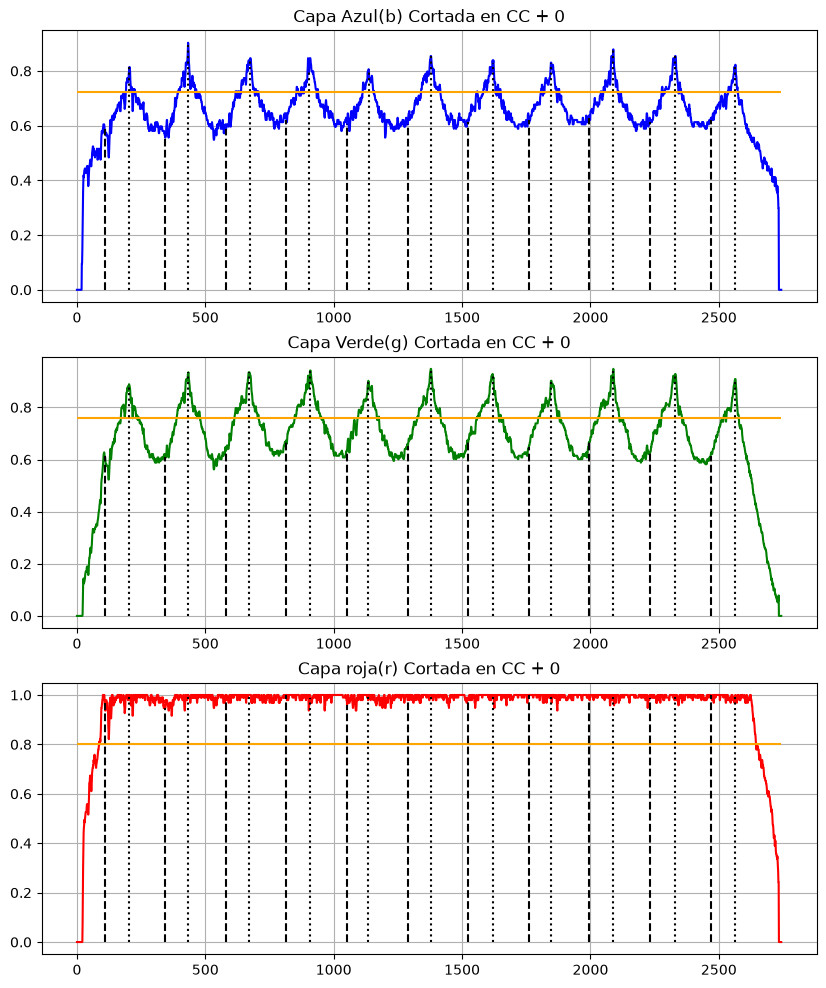

In [75]:
crr_cc = 0

maxs_g = []

b_crossplane = placa_recorte_borde_b[
    centro_rotacion[1] - crr_cc
]

g_crossplane = placa_recorte_borde_g[
    centro_rotacion[1] - crr_cc
]

r_crossplane = placa_recorte_borde_r[
    centro_rotacion[1] - crr_cc
]


delta_0 = 0.8 # 80% de diferencia con el valor del centro de referencia

# Algoritmo de identificacion de maximos en regiones especificas de la placa

max_list_b_crossplane, lista_intervalos_b = posiciones_maximos(b_crossplane)

max_list_g_crossplane, lista_intervalos_g = posiciones_maximos(g_crossplane)

max_list_r_crossplane, lista_intervalos_r = posiciones_maximos(r_crossplane)

media_distancias_b_crossplane = media_dist_max(max_list_b_crossplane)
media_distancias_g_crossplane = media_dist_max(max_list_g_crossplane)
media_distancias_r_crossplane = media_dist_max(max_list_r_crossplane)

print(f"Media distancias entre puntos crossplane Azul(b): {np.round(media_distancias_b_crossplane, 3)} mm")
print(f"Media distancias entre puntos crossplane Verde(g): {np.round(media_distancias_g_crossplane, 3)} mm")
print(f"Media distancias entre puntos crossplane Rojo(r): {np.round(media_distancias_r_crossplane, 3)} mm")

# Graficamos
plt.figure(figsize = (10, 12))

plt.subplot(3, 1, 1)
plt.plot(b_crossplane, color = 'blue')
for a in max_list_b_crossplane:

    plt.vlines(int(a), np.min(b_crossplane), b_crossplane[a],
               colors = 'Black', linestyles = ':')

for e in lista_intervalos_g:

    plt.vlines(int(e), np.min(b_crossplane), b_crossplane[e],
                   colors = 'Black', linestyles = '--')
    

plt.hlines(delta_0 * np.max(b_crossplane), 0, np.shape(b_crossplane)[0],
           colors = "Orange", linestyles = '-')
plt.grid()
plt.title(f"Capa Azul(b) Cortada en CC + {crr_cc}")

plt.subplot(3, 1, 2)
plt.plot(g_crossplane, color = 'green')
plt.hlines(delta_0 * np.max(g_crossplane), 0, np.shape(g_crossplane)[0],
           colors = "Orange", linestyles = '-')

for a in max_list_g_crossplane:

    plt.vlines(int(a), np.min(g_crossplane), g_crossplane[a],
               colors = 'Black', linestyles = ':')

for e in lista_intervalos_g:

    plt.vlines(int(e), np.min(g_crossplane), g_crossplane[e],
                   colors = 'Black', linestyles = '--')

plt.grid()
plt.title(f"Capa Verde(g) Cortada en CC + {crr_cc}")

plt.subplot(3, 1, 3)
plt.plot(r_crossplane, color = 'red')
plt.hlines(delta_0 * np.max(r_crossplane), 0, np.shape(r_crossplane)[0],
           colors = "Orange", linestyles = '-')

for a in max_list_g_crossplane:

    plt.vlines(int(a), np.min(r_crossplane), r_crossplane[a],
               colors = 'Black', linestyles = ':')

for e in lista_intervalos_g:

    plt.vlines(int(e), np.min(r_crossplane), r_crossplane[e],
                   colors = 'Black', linestyles = '--')

plt.grid()
plt.title(f"Capa roja(r) Cortada en CC + {crr_cc}")

plt.show()

Bueno, en la identificacion de maximos tenemos un problema, si podemos recorrer adecuadamente los rangos, pero ese maximo puede estar en cualquier posicion del perfil global, por lo que hay que restringir nuevamente las posiciones al intervalo correspondiente y ajustar dinamicamente esa posicion en el rango global. Distancia entre puntos maximos:

Media distancias entre puntos crossplane Azul(b): 9.462 mm
Media distancias entre puntos crossplane Verde(g): 10.012 mm
Media distancias entre puntos crossplane Rojo(r): 9.991 mm


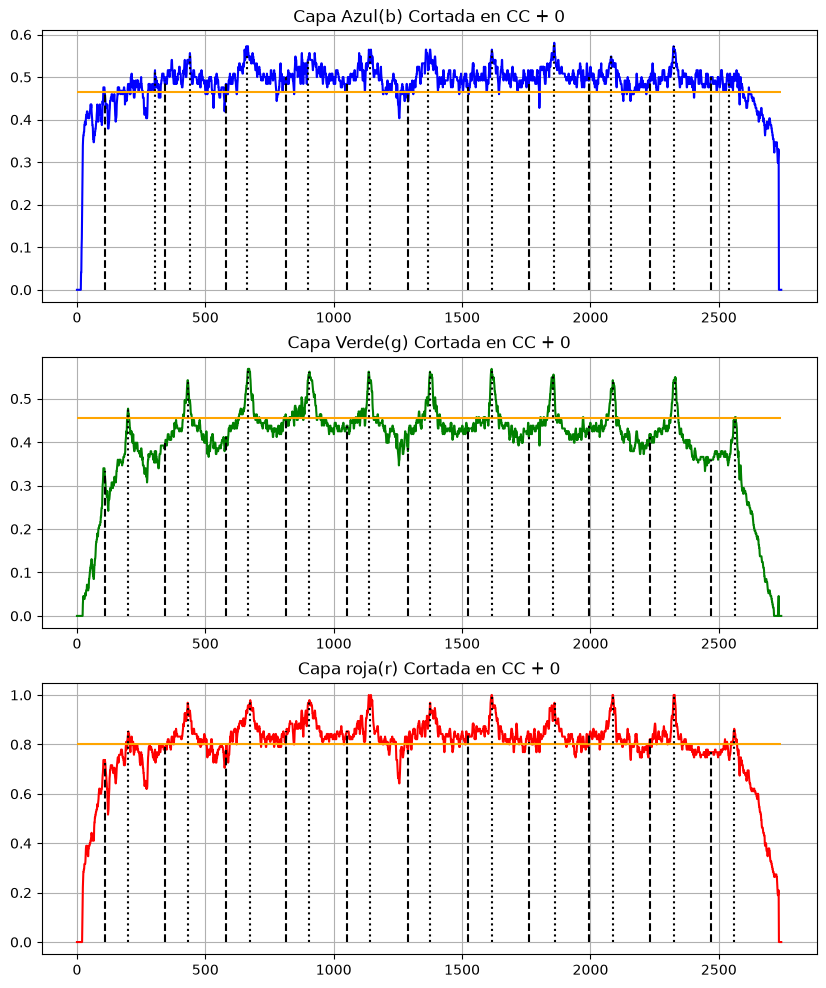

In [76]:
# crr_cc = puntos_rotados_tetha[0][1] + grosor_marco + 1

b_crossplane_lineas = placa_recorte_borde_b[
    puntos_rotados_tetha[0][1] + grosor_marco + 1
]

g_crossplane_lineas = placa_recorte_borde_g[
    puntos_rotados_tetha[0][1] + grosor_marco + 1
]

r_crossplane_lineas = placa_recorte_borde_r[
    puntos_rotados_tetha[0][1] + grosor_marco + 1
]


delta_0 = 0.8 # 80% de diferencia con el valor del centro de referencia

# Algoritmo de identificacion de maximos en regiones especificas de la placa

max_list_b_crossplane_lineas, lista_intervalos_b_lineas = posiciones_maximos(b_crossplane_lineas)

max_list_g_crossplane_lineas, lista_intervalos_g_lineas = posiciones_maximos(g_crossplane_lineas)

max_list_r_crossplane_lineas, lista_intervalos_r_lineas = posiciones_maximos(r_crossplane_lineas)

media_distancias_b_crossplane_lineas = media_dist_max(max_list_b_crossplane_lineas)
media_distancias_g_crossplane_lineas = media_dist_max(max_list_g_crossplane_lineas)
media_distancias_r_crossplane_lineas = media_dist_max(max_list_r_crossplane_lineas)

print(f"Media distancias entre puntos crossplane Azul(b): {np.round(media_distancias_b_crossplane_lineas, 3)} mm")
print(f"Media distancias entre puntos crossplane Verde(g): {np.round(media_distancias_g_crossplane_lineas, 3)} mm")
print(f"Media distancias entre puntos crossplane Rojo(r): {np.round(media_distancias_r_crossplane_lineas, 3)} mm")

# Graficamos
plt.figure(figsize = (10, 12))

plt.subplot(3, 1, 1)
plt.plot(b_crossplane_lineas, color = 'blue')
for a in max_list_b_crossplane_lineas:

    plt.vlines(int(a), np.min(b_crossplane_lineas), b_crossplane_lineas[a],
               colors = 'Black', linestyles = ':')

for e in lista_intervalos_b_lineas:

    plt.vlines(int(e), np.min(b_crossplane_lineas), b_crossplane_lineas[e],
                   colors = 'Black', linestyles = '--')
    

plt.hlines(delta_0 * np.max(b_crossplane_lineas), 0, np.shape(b_crossplane_lineas)[0],
           colors = "Orange", linestyles = '-')
plt.grid()
plt.title(f"Capa Azul(b) Cortada en CC + {crr_cc}")

plt.subplot(3, 1, 2)
plt.plot(g_crossplane_lineas, color = 'green')
plt.hlines(delta_0 * np.max(g_crossplane_lineas), 0, np.shape(g_crossplane_lineas)[0],
           colors = "Orange", linestyles = '-')

for a in max_list_g_crossplane_lineas:

    plt.vlines(int(a), np.min(g_crossplane_lineas), g_crossplane_lineas[a],
               colors = 'Black', linestyles = ':')

for e in lista_intervalos_g_lineas:

    plt.vlines(int(e), np.min(g_crossplane_lineas), g_crossplane_lineas[e],
                   colors = 'Black', linestyles = '--')

plt.grid()
plt.title(f"Capa Verde(g) Cortada en CC + {crr_cc}")

plt.subplot(3, 1, 3)
plt.plot(r_crossplane_lineas, color = 'red')
plt.hlines(delta_0 * np.max(r_crossplane_lineas), 0, np.shape(r_crossplane_lineas)[0],
           colors = "Orange", linestyles = '-')

for a in max_list_r_crossplane_lineas:

    plt.vlines(int(a), np.min(r_crossplane_lineas), r_crossplane_lineas[a],
               colors = 'Black', linestyles = ':')

for e in lista_intervalos_r_lineas:

    plt.vlines(int(e), np.min(r_crossplane_lineas), r_crossplane_lineas[e],
                   colors = 'Black', linestyles = '--')

plt.grid()
plt.title(f"Capa roja(r) Cortada en CC + {crr_cc}")

plt.show()

Deberiamos tambien medir las coincidencias entre lineas y maximos? Realmente podemos diferenciar que es una linea y que es un maximo?